
# Text Recognition Algorithm Theory

This chapter mainly introduces the theoretical knowledge of text recognition algorithms, including background introduction, algorithm classification and some classic paper ideas.

Through the study of this chapter, you can master:

1. The goal of text recognition

2. Classification of text recognition algorithms

3. Typical ideas of various algorithms


## 1 Background Introduction

Text recognition is a subtask of OCR (Optical Character Recognition), and its task is to recognize the text content of a fixed area. In the two-stage method of OCR, it is followed by text detection and converts image information into text information.

Specifically, the model inputs a positioned text line, and the model predicts the text content and confidence level in the picture. The visualization results are shown in the following figure:

<center><img src=https://ai-studio-static-online.cdn.bcebos.com/a7c3404f778b489db9c1f686c7d2ff4d63b67c429b454f98b91ade7b89f8e903 width="600"></center>

<center><img src=https://ai-studio-static-online.cdn.bcebos.com/e72b1d6f80c342ac951d092bc8c325149cebb3763ec849ec8a2f54e7c8ad60ca width="600"></center>
<br><center>Figure 1: Visualization results of model predicttion</center>

There are many application scenarios for text recognition, including document recognition, road sign recognition, license plate recognition, industrial number recognition, etc. According to actual scenarios, text recognition tasks can be divided into two categories: **Regular text recognition** and **Irregular Text recognition**.

* Regular text recognition: mainly refers to printed fonts, scanned text, etc., and the text is considered to be roughly in the horizontal position

* Irregular text recognition: It often appears in natural scenes, and due to the huge differences in text curvature, direction, deformation, etc., the text is often not in the horizontal position, and there are problems such as bending, occlusion, and blurring.


The figure below shows the data patterns of IC15 and IC13, which represent irregular text and regular text respectively. It can be seen that irregular text often has problems such as distortion, blurring, and large font differences. It is closer to the real scene and is also more challenging.

Therefore, the current major algorithms are trying to obtain higher indicators on irregular data sets.

<center><img src=https://ai-studio-static-online.cdn.bcebos.com/bae4fce1370b4751a3779542323d0765a02a44eace7b44d2a87a241c13c6f8cf width="400">
<br><center>Figure 2: IC15 picture sample (irregular text)</center>
<img src=https://ai-studio-static-online.cdn.bcebos.com/b55800d3276f4f5fad170ea1b567eb770177fce226f945fba5d3247a48c15c34 width="400"></center>
<br><center>Figure 3: IC13 picture sample (rule text)</center>


When comparing the capabilities of different recognition algorithms, they are often compared on these two types of public data sets. Comparing the effects on multiple dimensions, currently the more common English benchmark data sets are classified as follows:

<center><img src=https://ai-studio-static-online.cdn.bcebos.com/4d0aada261064031a16816b39a37f2ff6af70dbb57004cb7a106ae6485f14684 width="600"></center>
<br><center>Figure 4: Common English benchmark data sets</center>

## 2 Text Recognition Algorithm Classification

In the traditional text recognition method, the task is divided into 3 steps, namely image preprocessing, character segmentation and character recognition. It is necessary to model a specific scene, and it will become invalid once the scene changes. In the face of complex text backgrounds and scene changes, methods based on deep learning have better performance.

Most existing recognition algorithms can be represented by the following unified framework, and the algorithm flow is divided into 4 stages:

![](https://ai-studio-static-online.cdn.bcebos.com/a2750f4170864f69a3af36fc13db7b606d851f2f467d43cea6fbf3521e65450f)


We have sorted out the mainstream algorithm categories and main papers, refer to the following table:
<center>
  
| Algorithm category | Main ideas | Main papers |
| -------- | --------------- | -------- |
| Traditional algorithm | Sliding window, character extraction, dynamic programming |-|
| ctc | Based on ctc method, sequence is not aligned, faster recognition | CRNN, Rosetta |
| Attention | Attention-based method, applied to unconventional text | RARE, DAN, PREN |
| Transformer | Transformer-based method | SRN, NRTR, Master, ABINet |
| Correction | The correction module learns the text boundary and corrects it to the horizontal direction | RARE, ASTER, SAR |
| Segmentation | Based on the method of segmentation, extract the character position and then do classification | Text Scanner, Mask TextSpotter |
  
</center>


### 2.1 Regular Text Recognition


There are two mainstream algorithms for text recognition, namely the CTC (Conectionist Temporal Classification)-based algorithm and the Sequence2Sequence algorithm. The difference is mainly in the decoding stage.

The CTC-based algorithm connects the encoded sequence to the CTC for decoding; the Sequence2Sequence-based method connects the sequence to the Recurrent Neural Network (RNN) module for cyclic decoding. Both methods have been verified to be effective and mainstream. Two major practices.

<center><img src=https://ai-studio-static-online.cdn.bcebos.com/f64eee66e4a6426f934c1befc3b138629324cf7360c74f72bd6cf3c0de9d49bd width="600"></center>
<br><center>Figure 5: Left: CTC-based method, right: Sequece2Sequence-based method </center>


#### 2.1.1 Algorithm Based on CTC

The most typical algorithm based on CTC is CRNN (Convolutional Recurrent Neural Network) [1], and its feature extraction part uses mainstream convolutional structures, commonly used ResNet, MobileNet, VGG, etc. Due to the particularity of text recognition tasks, there is a large amount of contextual information in the input data. The convolution kernel characteristics of convolutional neural networks make it more focused on local information and lack long-dependent modeling capabilities, so it is difficult to use only convolutional networks. Dig into the contextual connections between texts. In order to solve this problem, the CRNN text recognition algorithm introduces the bidirectional LSTM (Long Short-Term Memory) to enhance the context modeling. Experiments prove that the bidirectional LSTM module can effectively extract the context information in the picture. Finally, the output feature sequence is input to the CTC module, and the sequence result is directly decoded. This structure has been verified to be effective and widely used in text recognition tasks. Rosetta [2] is a recognition network proposed by FaceBook, which consists of a fully convolutional model and CTC. Gao Y [3] et al. used CNN convolution instead of LSTM, with fewer parameters, and the performance improvement accuracy was the same.

<center><img src=https://ai-studio-static-online.cdn.bcebos.com/d3c96dd9e9794fddb12fa16f926abdd3485194f0a2b749e792e436037490899b width="600"></center>
<center>Figure 6:  CRNN structure diagram </center>


#### 2.1.2 Sequence2Sequence algorithm

In the Sequence2Sequence algorithm, the Encoder encodes all input sequences into a unified semantic vector, which is then decoded by the Decoder. In the decoding process of the decoder, the output of the previous moment is continuously used as the input of the next moment, and the decoding is performed in a loop until the stop character is output. The general encoder is an RNN. For each input word, the encoder outputs a vector and hidden state, and uses the hidden state for the next input word to get the semantic vector in a loop; the decoder is another RNN, which receives the encoder Output a vector and output a series of words to create a transformation. Inspired by Sequence2Sequence in the field of translation, Shi [4] proposed an attention-based codec framework to recognize text. In this way, rnn can learn character-level language models hidden in strings from training data.

<center><img src=https://ai-studio-static-online.cdn.bcebos.com/f575333696b7438d919975dc218e61ccda1305b638c5497f92b46a7ec3b85243 width="400" hight="500"></center>
<center>Figure 7:  Sequence2Sequence structure diagram </center>

The above two algorithms have very good effects on regular text, but due to the limitations of network design, this type of method is difficult to solve the task of irregular text recognition of bending and rotation. In order to solve such problems, some algorithm researchers have proposed a series of improved algorithms on the basis of the above two types of algorithms.

### 2.2 Irregular Text Recognition

* Irregular text recognition algorithms can be divided into 4 categories: correction-based methods; Attention-based methods; segmentation-based methods; and Transformer-based methods.

#### 2.2.1 Correction-based Method

The correction-based method uses some visual transformation modules to convert irregular text into regular text as much as possible, and then uses conventional methods for recognition.

The RARE [4] model first proposed a correction scheme for irregular text. The entire network is divided into two main parts: a spatial transformation network STN (Spatial Transformer Network) and a recognition network based on Sequence2Squence. Among them, STN is the correction module. Irregular text images enter STN and are transformed into a horizontal image through TPS (Thin-Plate-Spline). This transformation can correct curved and transmissive text to a certain extent, and send it to sequence recognition after correction. Network for decoding.

<center><img src=https://ai-studio-static-online.cdn.bcebos.com/66406f89507245e8a57969b9bed26bfe0227a8cf17a84873902dd4a464b97bb5 width="600"></center>
<center>Figure 8:  RARE structure diagram </center>

The RARE paper pointed out that this method has greater advantages in irregular text data sets, especially comparing the two data sets CUTE80 and SVTP, which are more than 5 percentage points higher than CRNN, which proves the effectiveness of the correction module. Based on this [6] also combines a text recognition system with a spatial transformation network (STN) and an attention-based sequence recognition network.

Correction-based methods have better migration. In addition to Attention-based methods such as RARE, STAR-Net [5] applies correction modules to CTC-based algorithms, which is also a good improvement compared to traditional CRNN.

#### 2.2.2 Attention-based Method

The Attention-based method mainly focuses on the correlation between the parts of the sequence. This method was first proposed in the field of machine translation. It is believed that the result of the current word in the process of text translation is mainly affected by certain words, so it needs to be The decisive word has greater weight. The same is true in the field of text recognition. When decoding the encoded sequence, each step selects the appropriate context to generate the next state, which is conducive to obtaining more accurate results.

R^2AM [7] first introduced Attention into the field of text recognition. The model first extracts the encoded image features from the input image through a recursive convolutional layer, and then uses the implicitly learned character-level language statistics to decode the output through a recurrent neural network character. In the decoding process, the Attention mechanism is introduced to realize soft feature selection to make better use of image features. This selective processing method is more in line with human intuition.

<center><img src=https://ai-studio-static-online.cdn.bcebos.com/a64ef10d4082422c8ac81dcda4ab75bf1db285d6b5fd462a8f309240445654d5 width="600"></center>
<center>Figure 9:  R^2AM structure drawing </center>

A large number of algorithms will be explored and updated in the field of Attention in the future. For example, SAR[8] extends 1D attention to 2D attention. The RARE mentioned in the correction module is also a method based on Attention. Experiments prove that the Attention-based method has a good accuracy improvement compared with the CTC method.

<center><img src=https://ai-studio-static-online.cdn.bcebos.com/4e2507fb58d94ec7a9b4d17151a986c84c5053114e05440cb1e7df423d32cb02 width="600"></center>
<center>Figure 10: Attention diagram</center>


#### 2.2.3 Method Based on Segmentation

The method based on segmentation is to treat each character of the text line as an independent individual, and it is easier to recognize the segmented individual characters than to recognize the entire text line after correction. It attempts to locate the position of each character in the input text image, and applies a character classifier to obtain these recognition results, simplifying the complex global problem into a local problem solving, and it has a relatively good effect in the irregular text scene. However, this method requires character-level labeling, and there is a certain degree of difficulty in data acquisition. Lyu [9] et al. proposed an instance word segmentation model for word recognition, which uses a method based on FCN (Fully Convolutional Network) in its recognition part. [10] Considering the problem of text recognition from a two-dimensional perspective, a character attention FCN is designed to solve the problem of text recognition. When the text is bent or severely distorted, this method has better positioning results for both regular and irregular text.

<center><img src=https://ai-studio-static-online.cdn.bcebos.com/fd3e8ef0d6ce4249b01c072de31297ca5d02fc84649846388f890163b624ff10 width="800"></center>
<center>Figure 11: Mask TextSpotter structure diagram </center>



#### 2.2.4 Transformer-based Method

With the rapid development of Transformer, both classification and detection fields have verified the effectiveness of Transformer in visual tasks. As mentioned in the regular text recognition part, CNN has limitations in long-dependency modeling. The Transformer structure just solves this problem. It can focus on global information in the feature extractor and can replace additional context modeling modules (LSTM ).

Part of the text recognition algorithm uses Transformer's Encoder structure and convolution to extract sequence features. The Encoder is composed of multiple blocks stacked by MultiHeadAttentionLayer and Positionwise Feedforward Layer. The self-attention in MulitHeadAttention uses matrix multiplication to simulate the timing calculation of RNN, breaking the barrier of long-term dependence on timing in RNN. There are also some algorithms that use Transformer's Decoder module to decode, which can obtain stronger semantic information than traditional RNNs, and parallel computing has higher efficiency.

The SRN[11] algorithm connects the Encoder module of Transformer to ResNet50 to enhance the 2D visual features. A parallel attention module is proposed, which uses the reading order as a query, making the calculation independent of time, and finally outputs the aligned visual features of all time steps in parallel. In addition, SRN also uses Transformer's Eecoder as a semantic module to integrate the visual information and semantic information of the picture, which has greater benefits in irregular text such as occlusion and blur.

NRTR [12] uses a complete Transformer structure to encode and decode the input picture, and only uses a few simple convolutional layers for high-level feature extraction, and verifies the effectiveness of the Transformer structure in text recognition.

<center><img src=https://ai-studio-static-online.cdn.bcebos.com/e7859f4469a842f0bd450e7e793a679d6e828007544241d09785c9b4ea2424a2 width="800"></center>
<center>Figure 12: NRTR structure drawing </center>

SRACN [13] uses Transformer's decoder to replace LSTM, once again verifying the efficiency and accuracy advantages of parallel training.

## 3 Summary

This section mainly introduces the theoretical knowledge and mainstream algorithms related to text recognition, including CTC-based methods, Sequence2Sequence-based methods, and segmentation-based methods. The ideas and contributions of classic papers are listed respectively. The next section will explain the practical course based on the CRNN algorithm, from networking to optimization to complete the entire training process,

## 4 Reference


[1]Shi, B., Bai, X., & Yao, C. (2016). An end-to-end trainable neural network for image-based sequence recognition and its application to scene text recognition. IEEE transactions on pattern analysis and machine intelligence, 39(11), 2298-2304.

[2]Fedor Borisyuk, Albert Gordo, and Viswanath Sivakumar. Rosetta: Large scale system for text detection and recognition in images. In Proceedings of the 24th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining, pages 71–79. ACM, 2018.

[3]Gao, Y., Chen, Y., Wang, J., & Lu, H. (2017). Reading scene text with attention convolutional sequence modeling. arXiv preprint arXiv:1709.04303.

[4]Shi, B., Wang, X., Lyu, P., Yao, C., & Bai, X. (2016). Robust scene text recognition with automatic rectification. In Proceedings of the IEEE conference on computer vision and pattern recognition (pp. 4168-4176).

[5] Star-Net  Max Jaderberg, Karen Simonyan, Andrew Zisserman, et al. Spa- tial transformer networks. In Advances in neural information processing systems, pages 2017–2025, 2015.

[6]Baoguang Shi, Mingkun Yang, XingGang Wang, Pengyuan Lyu, Xiang Bai, and Cong Yao. Aster: An attentional scene text recognizer with flexible rectification. IEEE transactions on pattern analysis and machine intelligence, 31(11):855–868, 2018.

[7] Lee C Y ,  Osindero S . Recursive Recurrent Nets with Attention Modeling for OCR in the Wild[C]// IEEE Conference on Computer Vision & Pattern Recognition. IEEE, 2016.

[8]Li, H., Wang, P., Shen, C., & Zhang, G. (2019, July). Show, attend and read: A simple and strong baseline for irregular text recognition. In Proceedings of the AAAI Conference on Artificial Intelligence (Vol. 33, No. 01, pp. 8610-8617).

[9]P. Lyu, C. Yao, W. Wu, S. Yan, and X. Bai. Multi-oriented scene text detection via corner localization and region segmentation. In Proc. CVPR, pages 7553–7563, 2018.

[10] Liao, M., Zhang, J., Wan, Z., Xie, F., Liang, J., Lyu, P., ... & Bai, X. (2019, July). Scene text recognition from two-dimensional perspective. In Proceedings of the AAAI Conference on Artificial Intelligence (Vol. 33, No. 01, pp. 8714-8721).

[11] Yu, D., Li, X., Zhang, C., Liu, T., Han, J., Liu, J., & Ding, E. (2020). Towards accurate scene text recognition with semantic reasoning networks. In Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (pp. 12113-12122).

[12] Sheng, F., Chen, Z., & Xu, B. (2019, September). NRTR: A no-recurrence sequence-to-sequence model for scene text recognition. In 2019 International Conference on Document Analysis and Recognition (ICDAR) (pp. 781-786). IEEE.

[13]Yang, L., Wang, P., Li, H., Li, Z., & Zhang, Y. (2020). A holistic representation guided attention network for scene text recognition. Neurocomputing, 414, 67-75.

[14]Wang, T., Zhu, Y., Jin, L., Luo, C., Chen, X., Wu, Y., ... & Cai, M. (2020, April). Decoupled attention network for text recognition. In Proceedings of the AAAI Conference on Artificial Intelligence (Vol. 34, No. 07, pp. 12216-12224).

[15] Wang, Y., Xie, H., Fang, S., Wang, J., Zhu, S., & Zhang, Y. (2021). From two to one: A new scene text recognizer with visual language modeling network. In Proceedings of the IEEE/CVF International Conference on Computer Vision (pp. 14194-14203).

[16] Fang, S., Xie, H., Wang, Y., Mao, Z., & Zhang, Y. (2021). Read Like Humans: Autonomous, Bidirectional and Iterative Language Modeling for Scene Text Recognition. In Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (pp. 7098-7107).

[17] Yan, R., Peng, L., Xiao, S., & Yao, G. (2021). Primitive Representation Learning for Scene Text Recognition. In Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (pp. 284-293).

# Text recognition practice

In the theoretical part of the previous chapter, the main methods in the field of text recognition were introduced. Among them, CRNN was proposed earlier and is currently more widely used in the industry. This chapter will introduce in detail how to build, train, evaluate and predict the CRNN text recognition model based on PaddleOCR. The data set is icdar 2015, in which there are 4468 pieces in the training set and 2077 pieces in the test set.


Through the study of this chapter, you can master:

1. How to use PaddleOCR whl package to quickly complete text recognition prediction

2. The basic principles and network structure of CRNN

3. The necessary steps and parameter adjustment methods for model training

4. Use a custom data set to train the network


## 1 Quick experience

### 1.1 Install related dependencies and whl packages

First confirm that paddle and paddleocr are installed. If they have been installed, ignore this step.

In [ ]:
#!pip install paddleocr
import paddleocr
# For the first run, you need to open the comment on the next line and download the PaddleOCR code
#!git clone https://gitee.com/paddlepaddle/PaddleOCR
import os
# Modify the default directory where the code runs to /home/aistudio/PaddleOCR
os.chdir("PaddleOCR")

### 1.2 Quickly predict text content

The PaddleOCR whl package will automatically download the ppocr lightweight model as the default model

The following shows how to use the whl package for recognition prediction:

Test picture:

![](./PaddleOCR/crops/03/crop_1.png)

In [1]:
from paddleocr import PaddleOCR

ocr = PaddleOCR()  # need to run only once to download and load model into memory
img_path = 'crops/03/crop_1.png'
result = ocr.ocr(img_path, det=False)
for line in result:
    print(line)

download https://paddleocr.bj.bcebos.com/PP-OCRv3/chinese/ch_PP-OCRv3_rec_infer.tar to /home/greystone/.paddleocr/whl/rec/ch/ch_PP-OCRv3_rec_infer/ch_PP-OCRv3_rec_infer.tar


100%|██████████████████████████████████████| 11.9M/11.9M [00:12<00:00, 962kiB/s]

[2022/12/26 10:28:14] ppocr DEBUG: Namespace(alpha=1.0, benchmark=False, beta=1.0, cls_batch_num=6, cls_image_shape='3, 48, 192', cls_model_dir='/home/greystone/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer', cls_thresh=0.9, cpu_threads=10, crop_res_save_dir='./output', det=True, det_algorithm='DB', det_box_type='quad', det_db_box_thresh=0.6, det_db_score_mode='fast', det_db_thresh=0.3, det_db_unclip_ratio=1.5, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_east_score_thresh=0.8, det_limit_side_len=960, det_limit_type='max', det_model_dir='/home/greystone/.paddleocr/whl/det/ch/ch_PP-OCRv3_det_infer', det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, det_pse_thresh=0, det_sast_nms_thresh=0.2, det_sast_score_thresh=0.5, draw_img_save_dir='./inference_results', drop_score=0.5, e2e_algorithm='PGNet', e2e_char_dict_path='./ppocr/utils/ic15_dict.txt', e2e_limit_side_len=768, e2e_limit_type='max', e2e_model_dir=None, e2e_pgnet_mode='fast', e2e_pgnet_score_thresh=0.5,

[2022/12/26 10:28:14] ppocr WARNING: Since the angle classifier is not initialized, the angle classifier will not be uesd during the forward process
[('Google Model GZRNL', 0.9530590772628784)]


After executing the above code block, the recognition result and recognition confidence will be returned

```
('SLOW', 0.9776376)
```

At this point, you have mastered how to use the PaddleOCR whl package to make predictions. There are more test pictures in the `./work/` path, you can try other picture results.

## 2 Detailed explanation of forecasting principle

In the first section, paddleocr loads the trained CRNN recognition model for prediction. This section will introduce the principle and process of CRNN in detail.

### 2.1 Category

CRNN is an algorithm based on CTC. It is located in the following position in the classification diagram introduced in the theory section. It can be seen that CRNN is mainly used to solve regular texts, and the CTC-based algorithm has a faster prediction speed and is well suited for long texts. Therefore, CRNN is the Chinese recognition algorithm chosen by PPOCR.
<center><img src=https://ai-studio-static-online.cdn.bcebos.com/0e74d46918e5423684e06df8e6eb992cf9f7c485d6c142fb98cc263714559898 width="600"></center>


### 2.2 Detailed algorithm

CRNN's network structure system is as follows, from bottom to top, there are three parts: convolutional layer, recursive layer, and transcription layer:

<center><img src=https://ai-studio-static-online.cdn.bcebos.com/f6fae3ff66bd413fa182d75782034a2af6aab1994fa148a08e6565f3fb75b18d width="600"></center>

1. Backbone:

As the underlying backbone network, the convolutional network is used to extract feature sequences from the input image. Since `conv`, `max-pooling`, `elementwise` and activation functions all act on the local area, they are translation invariant. Therefore, each column of the feature map corresponds to a rectangular area (called a receptive field) of the original image, and these rectangular areas are in the same order from left to right as their corresponding columns on the feature map. Since CNN needs to scale the input image to a fixed size to meet its fixed input dimensionality, it is not suitable for sequence objects that vary greatly in length. In order to better support variable length sequences, CRNN sends the feature vector output from the last layer of backbone to the RNN layer and converts it into sequence features.

<center><img src=https://ai-studio-static-online.cdn.bcebos.com/6694818123724b0d92d05b63dc9dfb08c7ced6c47c3b4f4d9b110ae9ccfe941d width="600"></center>

2. neck:

The recursive layer builds a recursive network on the basis of the convolutional network, converts image features into sequence features, and predicts the label distribution of each frame.
RNN has a strong ability to capture sequence context information. Image-based sequence recognition using contextual cues is more effective than processing each pixel individually. Taking scene text recognition as an example, wide characters may require several consecutive frames to be fully described. In addition, some ambiguous characters are easier to distinguish when observing their context. Second, RNN can back-propagate the error differential back to the convolutional layer, so that the network can be trained uniformly. Third, RNN can operate on sequences of any length, which solves the problem of text images becoming longer. CRNN uses double-layer LSTM as the recursive layer to solve the problem of gradient disappearance and gradient explosion in the training process of long sequences.

<center><img src=https://ai-studio-static-online.cdn.bcebos.com/41cdb7fb08fb4b55923b0baf66b783e46fd063223d05416fa952369ad20ac83c width="600"></center>


3. head:

The transcription layer converts the prediction of each frame into the final label sequence through the fully connected network and the softmax activation function. Finally, CTC Loss is used to complete the joint training of CNN and RNN without sequence alignment. CTC has a special merging sequence mechanism. After LSTM outputs the sequence, it needs to be classified in time sequence to obtain the prediction result. There may be multiple time steps corresponding to the same category, so the same results need to be combined. In order to avoid merging the repeated characters that exist, CTC introduced a `blank` character to be inserted between the repeated characters.

<center><img src=https://ai-studio-static-online.cdn.bcebos.com/bea6be2f5d9d4ac791118737c3f2f140a2a261e0d8a540a3b0ef239b6bcb2c43 width="600"></center>


### 2.3 Code Implementation

The entire network structure is very concise, and the code implementation is relatively simple. Modules can be built in sequence following the forecasting process. This section needs to be completed: data input, backbone construction, neck construction, head construction.

**[Data Input]**

The data needs to be scaled to a uniform size (3,32,320) before being sent to the network, and normalization is completed. The data enhancement part required during training is omitted here, and a single image is used as an example to show the necessary steps of preprocessing [source code location](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.3/ppocr/data/imaug/rec_img_aug.py#L126):


In [2]:
import cv2
import math
import numpy as np

def resize_norm_img(img):
    """
    Data scaling and normalization
    :param img: input picture
    """

    # Default input size
    imgC = 3
    imgH = 32
    imgW = 320

    # The real height and width of the picture
    h, w = img.shape[:2]
    # Picture real aspect ratio
    ratio = w / float(h)

    # Scaling
    if math.ceil(imgH * ratio) > imgW:
        # If greater than the default width, the width is imgW
        resized_w = imgW
    else:
        # If it is smaller than the default width, the actual width of the picture shall prevail
        resized_w = int(math.ceil(imgH * ratio))
    # Zoom
    resized_image = cv2.resize(img, (resized_w, imgH))
    resized_image = resized_image.astype('float32')
    # Normalized
    resized_image = resized_image.transpose((2, 0, 1)) / 255
    resized_image -= 0.5
    resized_image /= 0.5
    # For the position with insufficient width, add 0
    padding_im = np.zeros((imgC, imgH, imgW), dtype=np.float32)
    padding_im[:, :, 0:resized_w] = resized_image
    # Transpose the image after padding for visualization
    draw_img = padding_im.transpose((1,2,0))
    return padding_im, draw_img


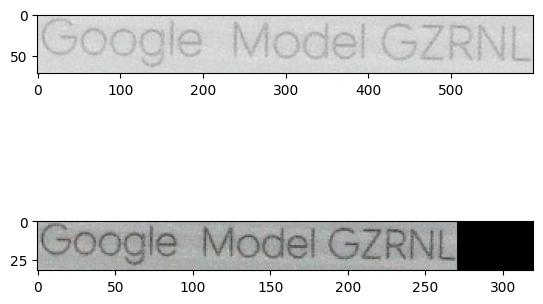

In [3]:
import matplotlib.pyplot as plt
# Read the picture
raw_img = cv2.imread(img_path)
plt.figure()
plt.subplot(2,1,1)
# Visualize the original image
plt.imshow(raw_img)
# Scale and normalize
padding_im, draw_img = resize_norm_img(raw_img)
plt.subplot(2,1,2)
# Visual network input diagram
plt.imshow(draw_img)
plt.show()

**[Network Structure]**

* backbone

PaddleOCR uses MobileNetV3 as the backbone network. The networking sequence is consistent with the network structure. First, define the public modules in the network ([source code location](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.3/ppocr/modeling/backbones/rec_mobilenet_v3.py)): `ConvBNLayer`, `ResidualUnit`, and `make_divisible`.

In [4]:
import paddle
import paddle.nn as nn
import paddle.nn.functional as F

class ConvBNLayer(nn.Layer):
    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size,
                 stride,
                 padding,
                 groups=1,
                 if_act=True,
                 act=None):
        """
        Convolutional BN layer
        :param in_channels: number of input channels
        :param out_channels: Number of output channels
        :param kernel_size: Convolution kernel size
        :parma stride: stride size
        :param padding: padding size
        :param groups: the number of groups of the two-dimensional convolutional layer
        :param if_act: whether to add activation function
        :param act: activation function
        """
        super(ConvBNLayer, self).__init__()
        self.if_act = if_act
        self.act = act
        self.conv = nn.Conv2D(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            groups=groups,
            bias_attr=False)

        self.bn = nn.BatchNorm(num_channels=out_channels, act=None)

    def forward(self, x):
        # conv layer
        x = self.conv(x)
        # batchnorm layer
        x = self.bn(x)
        # Whether to use activation function
        if self.if_act:
            if self.act == "relu":
                x = F.relu(x)
            elif self.act == "hardswish":
                x = F.hardswish(x)
            else:
                print("The activation function({}) is selected incorrectly.".
                      format(self.act))
                exit()
        return x

class SEModule(nn.Layer):
    def __init__(self, in_channels, reduction=4):
        """
        SE module
        :param in_channels: number of input channels
        :param reduction: channel zoom ratio
        """        
        super(SEModule, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2D(1)
        self.conv1 = nn.Conv2D(
            in_channels=in_channels,
            out_channels=in_channels // reduction,
            kernel_size=1,
            stride=1,
            padding=0)
        self.conv2 = nn.Conv2D(
            in_channels=in_channels // reduction,
            out_channels=in_channels,
            kernel_size=1,
            stride=1,
            padding=0)

    def forward(self, inputs):
        # Average pooling
        outputs = self.avg_pool(inputs)
        # First convolutional layer
        outputs = self.conv1(outputs)
        # relu activation function
        outputs = F.relu(outputs)
        # The second convolutional layer
        outputs = self.conv2(outputs)
        # hardsigmoid activation function
        outputs = F.hardsigmoid(outputs, slope=0.2, offset=0.5)
        return inputs * outputs


class ResidualUnit(nn.Layer):
    def __init__(self,
                 in_channels,
                 mid_channels,
                 out_channels,
                 kernel_size,
                 stride,
                 use_se,
                 act=None):
        """
        Residual layer
        :param in_channels: number of input channels
        :param mid_channels: number of intermediate channels
        :param out_channels: Number of output channels
        :param kernel_size: Convolution kernel size
        :parma stride: stride size
        :param use_se: whether to use se module
        :param act: activation function
        """ 
        super(ResidualUnit, self).__init__()
        self.if_shortcut = stride == 1 and in_channels == out_channels
        self.if_se = use_se

        self.expand_conv = ConvBNLayer(
            in_channels=in_channels,
            out_channels=mid_channels,
            kernel_size=1,
            stride=1,
            padding=0,
            if_act=True,
            act=act)
        self.bottleneck_conv = ConvBNLayer(
            in_channels=mid_channels,
            out_channels=mid_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=int((kernel_size - 1) // 2),
            groups=mid_channels,
            if_act=True,
            act=act)
        if self.if_se:
            self.mid_se = SEModule(mid_channels)
        self.linear_conv = ConvBNLayer(
            in_channels=mid_channels,
            out_channels=out_channels,
            kernel_size=1,
            stride=1,
            padding=0,
            if_act=False,
            act=None)

    def forward(self, inputs):
        x = self.expand_conv(inputs)
        x = self.bottleneck_conv(x)
        if self.if_se:
            x = self.mid_se(x)
        x = self.linear_conv(x)
        if self.if_shortcut:
            x = paddle.add(inputs, x)
        return x


def make_divisible(v, divisor=8, min_value=None):
    """
    Make sure to be divisible by 8
    """ 
    if min_value is None:
        min_value = divisor
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v


Use public modules to build backbone networks:

In [5]:
class MobileNetV3(nn.Layer):
    def __init__(self,
                 in_channels=3,
                 model_name='small',
                 scale=0.5,
                 small_stride=None,
                 disable_se=False,
                 **kwargs):
        super(MobileNetV3, self).__init__()
        self.disable_se = disable_se
        
        small_stride = [1, 2, 2, 2]

        if model_name == "small":
            cfg = [
                # k, exp, c,  se,     nl,  s,
                [3, 16, 16, True, 'relu', (small_stride[0], 1)],
                [3, 72, 24, False, 'relu', (small_stride[1], 1)],
                [3, 88, 24, False, 'relu', 1],
                [5, 96, 40, True, 'hardswish', (small_stride[2], 1)],
                [5, 240, 40, True, 'hardswish', 1],
                [5, 240, 40, True, 'hardswish', 1],
                [5, 120, 48, True, 'hardswish', 1],
                [5, 144, 48, True, 'hardswish', 1],
                [5, 288, 96, True, 'hardswish', (small_stride[3], 1)],
                [5, 576, 96, True, 'hardswish', 1],
                [5, 576, 96, True, 'hardswish', 1],
            ]
            cls_ch_squeeze = 576
        else:
            raise NotImplementedError("mode[" + model_name +
                                      "_model] is not implemented!")

        supported_scale = [0.35, 0.5, 0.75, 1.0, 1.25]
        assert scale in supported_scale, \
            "supported scales are {} but input scale is {}".format(supported_scale, scale)

        inplanes = 16
        # conv1
        self.conv1 = ConvBNLayer(
            in_channels=in_channels,
            out_channels=make_divisible(inplanes * scale),
            kernel_size=3,
            stride=2,
            padding=1,
            groups=1,
            if_act=True,
            act='hardswish')
        i = 0
        block_list = []
        inplanes = make_divisible(inplanes * scale)
        for (k, exp, c, se, nl, s) in cfg:
            se = se and not self.disable_se
            block_list.append(
                ResidualUnit(
                    in_channels=inplanes,
                    mid_channels=make_divisible(scale * exp),
                    out_channels=make_divisible(scale * c),
                    kernel_size=k,
                    stride=s,
                    use_se=se,
                    act=nl))
            inplanes = make_divisible(scale * c)
            i += 1
        self.blocks = nn.Sequential(*block_list)

        self.conv2 = ConvBNLayer(
            in_channels=inplanes,
            out_channels=make_divisible(scale * cls_ch_squeeze),
            kernel_size=1,
            stride=1,
            padding=0,
            groups=1,
            if_act=True,
            act='hardswish')

        self.pool = nn.MaxPool2D(kernel_size=2, stride=2, padding=0)
        self.out_channels = make_divisible(scale * cls_ch_squeeze)

    def forward(self, x):
        x = self.conv1(x)
        x = self.blocks(x)
        x = self.conv2(x)
        x = self.pool(x)
        return x


At this point, the definition of the backbone network is completed, and the entire network structure can be visualized through the paddle.summary structure:

In [6]:
# Define the network input shape
IMAGE_SHAPE_C = 3
IMAGE_SHAPE_H = 32
IMAGE_SHAPE_W = 320


# Visual network structure
paddle.summary(MobileNetV3(),[(1, IMAGE_SHAPE_C, IMAGE_SHAPE_H, IMAGE_SHAPE_W)])

-------------------------------------------------------------------------------
   Layer (type)         Input Shape          Output Shape         Param #    
     Conv2D-1        [[1, 3, 32, 320]]     [1, 8, 16, 160]          216      
    BatchNorm-1      [[1, 8, 16, 160]]     [1, 8, 16, 160]          32       
   ConvBNLayer-1     [[1, 3, 32, 320]]     [1, 8, 16, 160]           0       
     Conv2D-2        [[1, 8, 16, 160]]     [1, 8, 16, 160]          64       
    BatchNorm-2      [[1, 8, 16, 160]]     [1, 8, 16, 160]          32       
   ConvBNLayer-2     [[1, 8, 16, 160]]     [1, 8, 16, 160]           0       
     Conv2D-3        [[1, 8, 16, 160]]     [1, 8, 16, 160]          72       
    BatchNorm-3      [[1, 8, 16, 160]]     [1, 8, 16, 160]          32       
   ConvBNLayer-3     [[1, 8, 16, 160]]     [1, 8, 16, 160]           0       
AdaptiveAvgPool2D-1  [[1, 8, 16, 160]]       [1, 8, 1, 1]            0       
     Conv2D-4          [[1, 8, 1, 1]]        [1, 2, 1, 1]     

{'total_params': 259056, 'trainable_params': 252896}

In [7]:
# Picture input backbone network
backbone = MobileNetV3()
# Convert numpy data to Tensor
input_data = paddle.to_tensor([padding_im])
# Backbone network output
feature = backbone(input_data)
# View the latitude of the feature map
print("backbone output:", feature.shape)

backbone output: [1, 288, 1, 80]


* neck

The neck part converts the visual feature map output by the backbone into a 1-dimensional vector input and sends it to the LSTM network, and outputs the sequence feature ([source code location](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.3/ppocr/modeling/necks/rnn.py)):

In [8]:
class Im2Seq(nn.Layer):
    def __init__(self, in_channels, **kwargs):
        """
        Image feature is converted to sequence feature
        :param in_channels: number of input channels
        """ 
        super().__init__()
        self.out_channels = in_channels

    def forward(self, x):
        B, C, H, W = x.shape
        assert H == 1
        x = x.squeeze(axis=2)
        x = x.transpose([0, 2, 1])  # (NWC)(batch, width, channels)
        return x

class EncoderWithRNN(nn.Layer):
    def __init__(self, in_channels, hidden_size):
        super(EncoderWithRNN, self).__init__()
        self.out_channels = hidden_size * 2
        self.lstm = nn.LSTM(
            in_channels, hidden_size, direction='bidirectional', num_layers=2)

    def forward(self, x):
        x, _ = self.lstm(x)
        return x


class SequenceEncoder(nn.Layer):
    def __init__(self, in_channels, hidden_size=48, **kwargs):
        """
        Sequence encoding
        :param in_channels: number of input channels
        :param hidden_size: hidden layer size
        """ 
        super(SequenceEncoder, self).__init__()
        self.encoder_reshape = Im2Seq(in_channels)

        self.encoder = EncoderWithRNN(
            self.encoder_reshape.out_channels, hidden_size)
        self.out_channels = self.encoder.out_channels

    def forward(self, x):
        x = self.encoder_reshape(x)
        x = self.encoder(x)
        return x


In [9]:
neck = SequenceEncoder(in_channels=288)
sequence = neck(feature)
print("sequence shape:", sequence.shape)

sequence shape: [1, 80, 96]


* head
The prediction header part is composed of a fully connected layer and softmax, which is used to calculate the label probability distribution on the sequence feature time step. This example only supports the model to recognize 36 categories of lowercase English letters and numbers (26+10) ([source code location](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.3/ppocr/modeling/heads/rec_ctc_head.py)):

In [10]:
class CTCHead(nn.Layer):
    def __init__(self,
                 in_channels,
                 out_channels,
                 **kwargs):
        """
        CTC prediction layer
        :param in_channels: number of input channels
        :param out_channels: Number of output channels
        """ 
        super(CTCHead, self).__init__()
        self.fc = nn.Linear(
            in_channels,
            out_channels)
        
        # Thinking: How much should out_channels be equal to?
        self.out_channels = out_channels

    def forward(self, x):
        predicts = self.fc(x)
        result = predicts

        if not self.training:
            predicts = F.softmax(predicts, axis=2)
            result = predicts

        return result

In the case of random initialization of the network, the output results are disordered. After SoftMax, the prediction result with the highest probability at each time step can be obtained, where: `pred_id` represents the predicted tag ID, and `pre_scores` represents the predicted result Confidence:

In [11]:
ctc_head = CTCHead(in_channels=96, out_channels=37)
predict = ctc_head(sequence)
print("predict shape:", predict.shape)
result = F.softmax(predict, axis=2)
pred_id = paddle.argmax(result, axis=2)
pred_socres = paddle.max(result, axis=2)
print("pred_id:", pred_id)
print("pred_scores:", pred_socres)

predict shape: [1, 80, 37]
pred_id: Tensor(shape=[1, 80], dtype=int64, place=Place(cpu), stop_gradient=True,
       [[21, 6 , 6 , 6 , 6 , 6 , 6 , 12, 12, 12, 12, 12, 12, 6 , 6 , 6 , 6 , 6 ,
         6 , 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 6 , 6 , 6 , 6 , 12, 12,
         12, 12, 12, 18, 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 12,
         12, 12, 12, 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 12, 6 ,
         6 , 6 , 21, 21, 21, 21, 21, 8 ]])
pred_scores: Tensor(shape=[1, 80], dtype=float32, place=Place(cpu), stop_gradient=False,
       [[0.03448070, 0.03643723, 0.03725724, 0.03733703, 0.03690499, 0.03642410,
         0.03579718, 0.03515097, 0.03514040, 0.03569486, 0.03599986, 0.03611058,
         0.03520399, 0.03612693, 0.03612847, 0.03546398, 0.03513341, 0.03600449,
         0.03575080, 0.03561613, 0.03622955, 0.03581477, 0.03493807, 0.03460908,
         0.03508332, 0.03573656, 0.03569851, 0.03598542, 0.03641472, 0.03616988,
         0.03675976, 0.0368235

* Post-processing

The final result returned by the recognition network is the maximum index value at each time step, and the final expected output is the corresponding text result. Therefore, the post-processing of CRNN is a decoding process. The main logic is as follows:

In [12]:
def decode(text_index, text_prob=None, is_remove_duplicate=False):
    """ convert text-index into text-label. """
    character = "-0123456789abcdefghijklmnopqrstuvwxyz"
    result_list = []
    # Ignore tokens [0] represents the blank bit in ctc
    ignored_tokens = [0]
    batch_size = len(text_index)
    for batch_idx in range(batch_size):
        char_list = []
        conf_list = []
        for idx in range(len(text_index[batch_idx])):
            if text_index[batch_idx][idx] in ignored_tokens:
                continue
            # Combine the same characters between blank
            if is_remove_duplicate:
                # only for predict
                if idx > 0 and text_index[batch_idx][idx - 1] == text_index[
                        batch_idx][idx]:
                    continue
            # Store the decoded result in char_list
            char_list.append(character[int(text_index[batch_idx][
                idx])])
            # Record confidence
            if text_prob is not None:
                conf_list.append(text_prob[batch_idx][idx])
            else:
                conf_list.append(1)
        text = ''.join(char_list)
        # Output result
        result_list.append((text, np.mean(conf_list)))
    return result_list

In [13]:
pred_id = paddle.argmax(result, axis=2)
pred_socres = paddle.max(result, axis=2)
print(pred_id)
decode_out = decode(pred_id, pred_socres)
print("decode out:", decode_out)

Tensor(shape=[1, 80], dtype=int64, place=Place(cpu), stop_gradient=True,
       [[21, 6 , 6 , 6 , 6 , 6 , 6 , 12, 12, 12, 12, 12, 12, 6 , 6 , 6 , 6 , 6 ,
         6 , 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 6 , 6 , 6 , 6 , 12, 12,
         12, 12, 12, 18, 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 12,
         12, 12, 12, 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 12, 6 ,
         6 , 6 , 21, 21, 21, 21, 21, 8 ]])
decode out: [('k555555bbbbbb555555bbbbbbbbbbb5555bbbbbh5555555555555bbbb5555555555555b555kkkkk7', 0.036682684)]


In [17]:
# Replace the predicted result of the model
right_pred_id = paddle.to_tensor([[21, 6 , 6 , 6 , 6 , 6 , 6 , 12, 12, 12, 12, 12, 12, 6 , 6 , 6 , 6 , 6 ,
         6 , 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 6 , 6 , 6 , 6 , 12, 12,
         12, 12, 12, 18, 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 12,
         12, 12, 12, 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 6 , 12, 6 ,
         6 , 6 , 21, 21, 21, 21, 21, 8 ]])
tmp_scores = paddle.ones(shape=right_pred_id.shape)
out = decode(right_pred_id, tmp_scores)
print("out:",out)

out: [('k555555bbbbbb555555bbbbbbbbbbb5555bbbbbh5555555555555bbbb5555555555555b555kkkkk7', 1.0)]


The above steps complete the construction of the network and also realize a simple forward prediction process.

The untrained network cannot predict the result correctly. Therefore, it is necessary to define the loss function and optimization strategy to run the entire network. The network training principle will be described in detail below.

[download link](https://rrc.cvc.uab.es/?ch=4&com=downloads)

## 3. Detailed training principle
### 3.1 Prepare training data
PaddleOCR supports two data formats:
  -`lmdb` is used to train the data set (LMDBDataSet) stored in lmdb format;
  -`General Data` is used to train a data set (SimpleDataSet) stored in a text file;
 
  This time only introduces general data format reading

The default storage path of training data is `./train_data`, execute the following command to decompress the data:

After the decompression is complete, the training images are in the same folder, and there is a txt file (rec_gt_train.txt) that records the path and label of the image. The contents of the txt file are as follows:

```
"Image file name      Image annotation information"

train/word_1.png      Genaxis Theatre
train/word_2.png      [06]
...
```

**Note:** In the txt file, the picture path and picture label are divided by \t by default. If they are divided by other methods, it will cause training errors.


The data set should have the following file structure:
```
|-train_data
  |-ic15_data
    |- rec_gt_train.txt
    |- train
        |- word_001.png
        |- word_002.jpg
        |- word_003.jpg
        | ...
    |- rec_gt_test.txt
    |- test
        |- word_001.png
        |- word_002.jpg
        |- word_003.jpg
        | ...
```


In [27]:
# For the first run, you need to open the comment on the next line and download the PaddleOCR code
#!git clone https://gitee.com/paddlepaddle/PaddleOCR
import os
# Modify the default directory where the code runs to /home/aistudio/PaddleOCR
os.chdir("PaddleOCR")

In [28]:
!ls ./train_data/ic15_data

ch4_test_word_images_gt      rec_gt_test.txt
ch4_training_word_images_gt  rec_gt_train.txt


In [19]:
# Training set label
!wget -P ./train_data/ic15_data  https://paddleocr.bj.bcebos.com/dataset/rec_gt_train.txt

--2022-12-26 11:11:50--  https://paddleocr.bj.bcebos.com/dataset/rec_gt_train.txt
Resolving paddleocr.bj.bcebos.com (paddleocr.bj.bcebos.com)... 103.235.46.61, 2409:8c04:1001:1002:0:ff:b001:368a
Connecting to paddleocr.bj.bcebos.com (paddleocr.bj.bcebos.com)|103.235.46.61|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 116568 (114K) [text/plain]
Saving to: ‘./train_data/ic15_data/rec_gt_train.txt’

rec_gt_train.txt    100%[===================>] 113.84K   183KB/s    in 0.6s    

2022-12-26 11:11:51 (183 KB/s) - ‘./train_data/ic15_data/rec_gt_train.txt’ saved [116568/116568]



In [20]:
# Test Set Label
!wget -P ./train_data/ic15_data  https://paddleocr.bj.bcebos.com/dataset/rec_gt_test.txt

--2022-12-26 11:12:10--  https://paddleocr.bj.bcebos.com/dataset/rec_gt_test.txt
Resolving paddleocr.bj.bcebos.com (paddleocr.bj.bcebos.com)... 103.235.46.61, 2409:8c04:1001:1002:0:ff:b001:368a
Connecting to paddleocr.bj.bcebos.com (paddleocr.bj.bcebos.com)|103.235.46.61|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 51497 (50K) [text/plain]
Saving to: ‘./train_data/ic15_data/rec_gt_test.txt’

rec_gt_test.txt     100%[===================>]  50.29K   270KB/s    in 0.2s    

2022-12-26 11:12:11 (270 KB/s) - ‘./train_data/ic15_data/rec_gt_test.txt’ saved [51497/51497]



Confirm whether the data path in the configuration file is correct, take [rec_icdar15_train.yml](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.3/configs/rec/rec_icdar15_train.yml) as an example:
```yaml
Train:
  dataset:
    name: SimpleDataSet
    # Training data root directory
    data_dir: ./train_data/ic15_data/
    # Training data label
    label_file_list: ["./train_data/ic15_data/rec_gt_train.txt"]
    transforms:
      - DecodeImage: # load image
          img_mode: BGR
          channel_first: False
      - CTCLabelEncode: # Class handling label
      - RecResizeImg:
          image_shape: [3, 32, 100]  # [3,32,320]
      - KeepKeys:
          keep_keys: ['image', 'label', 'length'] # dataloader will return list in this order
  loader:
    shuffle: True
    batch_size_per_card: 256
    drop_last: True
    num_workers: 8
    use_shared_memory: False

Eval:
  dataset:
    name: SimpleDataSet
    # Evaluate the data root directory
    data_dir: ./train_data/ic15_data
    # Evaluation data label
    label_file_list: ["./train_data/ic15_data/rec_gt_test.txt"]
    transforms:
      - DecodeImage: # load image
          img_mode: BGR
          channel_first: False
      - CTCLabelEncode: # Class handling label
      - RecResizeImg:
          image_shape: [3, 32, 100]
      - KeepKeys:
          keep_keys: ['image', 'label', 'length'] # dataloader will return list in this order
  loader:
    shuffle: False
    drop_last: False
    batch_size_per_card: 256
    num_workers: 4
    use_shared_memory: False
```

In [30]:
# disalbe gpu config file
import yaml

with open("configs/rec/rec_icdar15_train.yml", "r") as f:
    config = yaml.safe_load(f)

config

{'Global': {'use_gpu': True,
  'epoch_num': 72,
  'log_smooth_window': 20,
  'print_batch_step': 10,
  'save_model_dir': './output/rec/ic15/',
  'save_epoch_step': 3,
  'eval_batch_step': [0, 2000],
  'cal_metric_during_train': True,
  'pretrained_model': None,
  'checkpoints': None,
  'save_inference_dir': './',
  'use_visualdl': False,
  'infer_img': 'doc/imgs_words_en/word_10.png',
  'character_dict_path': 'ppocr/utils/en_dict.txt',
  'max_text_length': 25,
  'infer_mode': False,
  'use_space_char': False,
  'save_res_path': './output/rec/predicts_ic15.txt'},
 'Optimizer': {'name': 'Adam',
  'beta1': 0.9,
  'beta2': 0.999,
  'lr': {'learning_rate': 0.0005},
  'regularizer': {'name': 'L2', 'factor': 0}},
 'Architecture': {'model_type': 'rec',
  'algorithm': 'CRNN',
  'Transform': None,
  'Backbone': {'name': 'MobileNetV3', 'scale': 0.5, 'model_name': 'large'},
  'Neck': {'name': 'SequenceEncoder',
   'encoder_type': 'rnn',
   'hidden_size': 96},
  'Head': {'name': 'CTCHead', 'fc_deca

In [31]:
# 1.gobal
use_gpu = config['Global']['use_gpu']
print("use_gpu: ",use_gpu)

epoch_num = config['Global']['epoch_num']
print("epoch_num: ",epoch_num)

pretrained_model = config['Global']['pretrained_model']
print("pretrained_model: ",pretrained_model)

infer_img = config['Global']['infer_img']
print("infer_img: ",infer_img)

save_model_dir = config['Global']['save_model_dir']
print("save_model_dir: ",save_model_dir)

save_res_path = config['Global']['save_res_path']
print("save_res_path: ",save_res_path)

# 2.optimizer
lr = config['Optimizer']['lr']['learning_rate']
print("lr: ",lr)

# 3.train
data_dir = config['Train']['dataset']['data_dir']
print("data_dir: ",data_dir)

label_file_list = config['Train']['dataset']['label_file_list'][0]
print(label_file_list)

# 4.eval
data_dir = config['Eval']['dataset']['data_dir']
print("data_dir: ",data_dir)

label_file_list = config['Eval']['dataset']['label_file_list'][0]
print(label_file_list)

use_gpu:  True
epoch_num:  72
pretrained_model:  None
infer_img:  doc/imgs_words_en/word_10.png
save_model_dir:  ./output/rec/ic15/
save_res_path:  ./output/rec/predicts_ic15.txt
lr:  0.0005
data_dir:  ./train_data/ic15_data/
./train_data/ic15_data/rec_gt_train.txt
data_dir:  ./train_data/ic15_data
./train_data/ic15_data/rec_gt_test.txt


### 3.2 Data preprocessing

The training data sent to the network needs to ensure that the dimensions within a batch are consistent. At the same time, in order to have a certain numerical comparison of the features between different dimensions, the data needs to be uniformly scaled **zoom** and **normalized**.

In order to increase the robustness of the model, suppress over-fitting and improve generalization performance, a certain **data augmentation** needs to be implemented.

* Scaling and normalization

Related content has been introduced in the second section, which is the last step before the picture is sent to the network. Call `resize_norm_img` to complete image scaling, padding and normalization.

* Data augmentation

A variety of data augmentation methods are implemented in PaddleOCR, such as: color inversion, random cutting, affine change, random noise, etc., here is a simple random cutting as an example, more augmentation methods can be referred to: [rec_img_aug.py](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.3/ppocr/data/imaug/rec_img_aug.py)

In [32]:
def get_crop(image):
    """
    random crop
    """
    import random
    h, w, _ = image.shape
    top_min = 1
    top_max = 8
    top_crop = int(random.randint(top_min, top_max))
    top_crop = min(top_crop, h - 1)
    crop_img = image.copy()
    ratio = random.randint(0, 1)
    if ratio:
        crop_img = crop_img[top_crop:h, :, :]
    else:
        crop_img = crop_img[0:h - top_crop, :, :]
    return crop_img


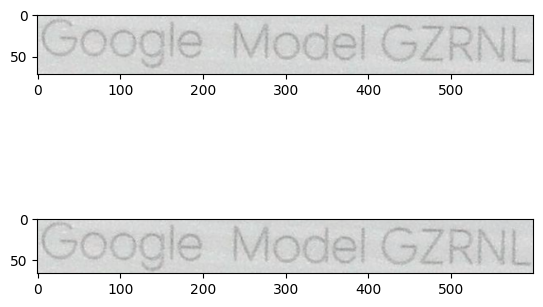

In [33]:
# Read the picture
raw_img = cv2.imread(img_path)
plt.figure()
plt.subplot(2,1,1)
# Visualize the original image
plt.imshow(raw_img)
# Random cut
crop_img = get_crop(raw_img)
plt.subplot(2,1,2)
# Visual augmentation graph
plt.imshow(crop_img)
plt.show()

### 3.3 Main training program

The entry code for model training is [train.py](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.3/tools/train.py), which shows the various modules required in training: `build dataloader`, `build post process`, `build model`, `build loss`, `build optim`, `build metric`, after connecting all parts in series, you can start training:

* Build dataloader

The training model requires the data to be formed into a specified number of batches, which are sequentially yielded during the training process. In this example, the [SimpleDataSet](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.3) implemented in PaddleOCR is called /ppocr/data/simple_dataset.py)

Based on the original code slightly modified, the main logic of returning a single piece of data is as follows:

In [57]:
def __getitem__(data_line, data_dir):
    import os
    mode = "train"
    delimiter = '\t'
    try:
        substr = data_line.strip("\n").split(delimiter)
        file_name = substr[0]
        label = substr[1]
        
        img_path = os.path.join(data_dir, file_name)
        data = {'img_path': img_path, 'label': label}
        if not os.path.exists(img_path):
            raise Exception("{} does not exist!".format(img_path))
        with open(data['img_path'], 'rb') as f:
            img = f.read()
            data['image'] = img
        # Pre-processing operation, comment out first
        # outs = transform(data, self.ops)
        outs = data
    except Exception as e:
        print("When parsing line {}, error happened with msg: {}".format(
                data_line, e))
        outs = None
    return outs

Suppose the current input label is `train/word_1.png Genaxis Theatre`, the path of the training data is `/home/aistudio/work/train_data/ic15_data/`, the result of parsing is a dictionary containing `img_path` `label` `image` three fields:

In [58]:
data_line = "train/word_1.png	Genaxis Theatre"
data_dir = "./train_data/ic15_data/"

item = __getitem__(data_line, data_dir)
print(item)

{'img_path': './train_data/ic15_data/train/word_1.png', 'label': 'Genaxis Theatre', 'image': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x00Y\x00\x00\x00\x0e\x08\x02\x00\x00\x00\xcb\xe2\'\xb7\x00\x00\x00\x01sRGB\x00\xae\xce\x1c\xe9\x00\x00\x00\x04gAMA\x00\x00\xb1\x8f\x0b\xfca\x05\x00\x00\x00 cHRM\x00\x00z&\x00\x00\x80\x84\x00\x00\xfa\x00\x00\x00\x80\xe8\x00\x00u0\x00\x00\xea`\x00\x00:\x98\x00\x00\x17p\x9c\xbaQ<\x00\x00\x0bmIDATHK\x8d\x96\xf9S[\xd7\x15\x80\x01\xa7\x93\xa4\xfd1\x99L\xea\x80\xc4\xa2]B\x0bb\xdf\x84\x04\x18\x8c\x01\xb3\x8aE\xec\x12\x02\t\xb4KhC\xfb\xbe=\xed\xbb\x04\xc2l&N\xd2\xb4\x93i\x9bv\xa6\x7fL\xdb\xe9d\xe2N\xd3d<u6C\x8f\xc0I\x9c\xb1\x7f\xc8\x9d\x8f3\xf7\xdd\xf7\xee\x9d{\xbfw\xceC\x95\xd3\xc3\xe3\x04\x02\xe1\xad\xb7\xde\xbazv\xf9\xcd7\xdf<~\xfc\xf8\xef\xff\xfc\xc7\xe7\x9f\xff\xfb\x7fO\x9f>y\xf2\xe4\xeb\xaf\xbf\xbe\xbc\xbc|\xedWU\xaf]\xb7\xab\xab\xab\xca\xca\xab\x8a\x8a\x8a\xca\xca\xca\xeb\x08\x97\xb7\xa0sY\xf1\xda\xf7\xdf?\x83vUYQUU\x05wa\xd6w\xcf\x9e\xdd\xbau\xeb\xf5

After realizing the return logic of a single piece of data, call `padde.io.Dataloader` to combine the data into a batch. For details, please refer to [build_dataloader](https://github.com/PaddlePaddle/PaddleOCR/blob/95c670faf6cf4551c841764cde43a4f4d9d5e634/ppocr/data/__init__.py#L52).


* build model

   The build model is to build the main network structure. The specific details are as described in "2.3 Code Implementation". This section will not introduce too much. For the code of each module, please refer to [modeling](https://github.com/PaddlePaddle/PaddleOCR/tree/release/2.3/ppocr/modeling)

* build loss
  
   The loss function of the CRNN model is CTC loss, and the flying paddle integrates the commonly used Loss function. You only need to call the implementation:

In [59]:
import paddle.nn as nn
class CTCLoss(nn.Layer):
    def __init__(self, use_focal_loss=False, **kwargs):
        super(CTCLoss, self).__init__()
        # blank is a meaningless connector for ctc
        self.loss_func = nn.CTCLoss(blank=0, reduction='none')

    def forward(self, predicts, batch):
        if isinstance(predicts, (list, tuple)):
            predicts = predicts[-1]
        # Transpose the prediction results of the head layer of the model, arranged along the channel layer
        predicts = predicts.transpose((1, 0, 2)) #[80,1,37]
        N, B, _ = predicts.shape
        preds_lengths = paddle.to_tensor([N] * B, dtype='int64')
        labels = batch[1].astype("int32")
        label_lengths = batch[2].astype('int64')
        # Calculate the loss function
        loss = self.loss_func(predicts, labels, preds_lengths, label_lengths)
        loss = loss.mean()
        return {'loss': loss}

* build post process

The specific details are also introduced in "2.3 Code Implementation", and the implementation logic is the same as before.

* build optim

The optimizer uses `Adam` and also calls the flying paddle API: `paddle.optimizer.Adam`

* build metric

The metric part is used to calculate model indicators. In PaddleOCR's text recognition, the prediction of the entire sentence is judged to be correct. Therefore, the main logic of the accuracy rate calculation is as follows:

In [60]:
def metric(preds, labels):    
    correct_num = 0
    all_num = 0
    norm_edit_dis = 0.0
    for (pred), (target) in zip(preds, labels):
        pred = pred.replace(" ", "")
        target = target.replace(" ", "")
        if pred == target:
            correct_num += 1
        all_num += 1
    correct_num += correct_num
    all_num += all_num
    return {
        'acc': correct_num / all_num,
    }

In [61]:
preds = ["aaa", "bbb", "ccc", "123", "456"]
labels = ["aaa", "bbb", "ddd", "123", "444"]
acc = metric(preds, labels)
print("acc:", acc)
# Among the five prediction results, 3 are completely correct, so the accuracy rate should be 0.6

acc: {'acc': 0.6}


Combining the above parts is the complete training process:

In [62]:

def main(config, device, logger, vdl_writer):
    # init dist environment
    if config['Global']['distributed']:
        dist.init_parallel_env()

    global_config = config['Global']

    # build dataloader
    train_dataloader = build_dataloader(config, 'Train', device, logger)
    if len(train_dataloader) == 0:
        logger.error(
            "No Images in train dataset, please ensure\n" +
            "\t1. The images num in the train label_file_list should be larger than or equal with batch size.\n"
            +
            "\t2. The annotation file and path in the configuration file are provided normally."
        )
        return

    if config['Eval']:
        valid_dataloader = build_dataloader(config, 'Eval', device, logger)
    else:
        valid_dataloader = None

    # build post process
    post_process_class = build_post_process(config['PostProcess'],
                                            global_config)

    # build model
    # for rec algorithm
    if hasattr(post_process_class, 'character'):
        char_num = len(getattr(post_process_class, 'character'))
        if config['Architecture']["algorithm"] in ["Distillation",
                                                   ]:  # distillation model
            for key in config['Architecture']["Models"]:
                config['Architecture']["Models"][key]["Head"][
                    'out_channels'] = char_num
        else:  # base rec model
            config['Architecture']["Head"]['out_channels'] = char_num

    model = build_model(config['Architecture'])
    if config['Global']['distributed']:
        model = paddle.DataParallel(model)

    # build loss
    loss_class = build_loss(config['Loss'])

    # build optim
    optimizer, lr_scheduler = build_optimizer(
        config['Optimizer'],
        epochs=config['Global']['epoch_num'],
        step_each_epoch=len(train_dataloader),
        parameters=model.parameters())

    # build metric
    eval_class = build_metric(config['Metric'])
    # load pretrain model
    pre_best_model_dict = load_model(config, model, optimizer)
    logger.info('train dataloader has {} iters'.format(len(train_dataloader)))
    if valid_dataloader is not None:
        logger.info('valid dataloader has {} iters'.format(
            len(valid_dataloader)))

    use_amp = config["Global"].get("use_amp", False)
    if use_amp:
        AMP_RELATED_FLAGS_SETTING = {
            'FLAGS_cudnn_batchnorm_spatial_persistent': 1,
            'FLAGS_max_inplace_grad_add': 8,
        }
        paddle.fluid.set_flags(AMP_RELATED_FLAGS_SETTING)
        scale_loss = config["Global"].get("scale_loss", 1.0)
        use_dynamic_loss_scaling = config["Global"].get(
            "use_dynamic_loss_scaling", False)
        scaler = paddle.amp.GradScaler(
            init_loss_scaling=scale_loss,
            use_dynamic_loss_scaling=use_dynamic_loss_scaling)
    else:
        scaler = None

    # start train
    program.train(config, train_dataloader, valid_dataloader, device, model,
                  loss_class, optimizer, lr_scheduler, post_process_class,
                  eval_class, pre_best_model_dict, logger, vdl_writer, scaler)

## 4. Complete training task

### 4.1 Start training

PaddleOCR recognition task is similar to detection task, which transmits parameters through configuration files.

To perform a complete model training, you first need to download the entire project and install related dependencies:

In [81]:
# Download the pre-trained model of MobileNetV3
!wget -nc -P ./pretrain_models/ https://paddleocr.bj.bcebos.com/dygraph_v2.0/en/rec_mv3_none_bilstm_ctc_v2.0_train.tar
# Decompress model parameters
!tar -xf pretrain_models/rec_mv3_none_bilstm_ctc_v2.0_train.tar && rm -rf pretrain_models/rec_mv3_none_bilstm_ctc_v2.0_train.tar

--2022-12-26 14:22:45--  https://paddleocr.bj.bcebos.com/dygraph_v2.0/en/rec_mv3_none_bilstm_ctc_v2.0_train.tar
Resolving paddleocr.bj.bcebos.com (paddleocr.bj.bcebos.com)... 103.235.46.61, 2409:8c04:1001:1002:0:ff:b001:368a
Connecting to paddleocr.bj.bcebos.com (paddleocr.bj.bcebos.com)|103.235.46.61|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 51200000 (49M) [application/x-tar]
Saving to: ‘./pretrain_models/rec_mv3_none_bilstm_ctc_v2.0_train.tar’

rec_mv3_none_bilstm 100%[===================>]  48.83M  2.76MB/s    in 20s     

2022-12-26 14:23:05 (2.48 MB/s) - ‘./pretrain_models/rec_mv3_none_bilstm_ctc_v2.0_train.tar’ saved [51200000/51200000]



Starting the training command is very simple, just specify the configuration file. In addition, in the command line, you can use `-o` to modify the parameter values in the configuration file. Start the training command as shown below

in:

* `Global.pretrained_model`: Loaded pretrained model path
* `Global.character_dict_path`: dictionary path (only 26 lowercase letters + numbers are supported here)
* `Global.eval_batch_step`: evaluation frequency
* `Global.epoch_num`: total number of training rounds



In [82]:
!ls train_data/ic15_data

rec_gt_test.txt  rec_gt_train.txt  test  train


In [83]:
# use_gpu:  True
# epoch_num:  72
# pretrained_model:  None
# infer_img:  doc/imgs_words_en/word_10.png
# save_model_dir:  ./output/rec/ic15/
# save_res_path:  ./output/rec/predicts_ic15.txt
# lr:  0.0005
# data_dir:  ./train_data/ic15_data/
# ./train_data/ic15_data/rec_gt_train.txt
# data_dir:  ./train_data/ic15_data
# ./train_data/ic15_data/rec_gt_test.txt

# disalbe gpu config file
import yaml

with open("configs/rec/rec_icdar15_train.yml", "r") as f:
    config = yaml.safe_load(f)
    
# 1.gobal
use_gpu = False
config['Global']['use_gpu']= use_gpu # 40 min

epoch_num = 1
config['Global']['epoch_num'] = epoch_num

# 3.train
data_dir = './train_data/ic15_data'
config['Train']['dataset']['data_dir'] = data_dir

label_file_list = './train_data/ic15_data/rec_gt_train.txt'
config['Train']['dataset']['label_file_list'][0] = label_file_list

# 4.eval
data_dir = './train_data/ic15_data'
config['Eval']['dataset']['data_dir'] = data_dir

label_file_list = './train_data/ic15_data/rec_gt_test.txt'
config['Eval']['dataset']['label_file_list'][0] = label_file_list

with open("configs/rec/rec_icdar15_train.yml", "w") as f:
    yaml.safe_dump(config, f)

Starting the training command is very simple, just specify the configuration file. In addition, in the command line, you can use `-o` to modify the parameter values in the configuration file. Start the training command as shown below

in:

* `Global.pretrained_model`: Loaded pretrained model path
* `Global.character_dict_path`: dictionary path (only 26 lowercase letters + numbers are supported here)
* `Global.eval_batch_step`: evaluation frequency
* `Global.epoch_num`: total number of training rounds



In [84]:
!python3 tools/train.py -c configs/rec/rec_icdar15_train.yml \
   -o Global.pretrained_model=rec_mv3_none_bilstm_ctc_v2.0_train/best_accuracy \
   Global.character_dict_path=ppocr/utils/ic15_dict.txt \
   Global.eval_batch_step=[0,200] \
   Global.epoch_num=20

[2022/12/26 14:23:14] ppocr INFO: Architecture : 
[2022/12/26 14:23:14] ppocr INFO:     Backbone : 
[2022/12/26 14:23:14] ppocr INFO:         model_name : large
[2022/12/26 14:23:14] ppocr INFO:         name : MobileNetV3
[2022/12/26 14:23:14] ppocr INFO:         scale : 0.5
[2022/12/26 14:23:14] ppocr INFO:     Head : 
[2022/12/26 14:23:14] ppocr INFO:         fc_decay : 0
[2022/12/26 14:23:14] ppocr INFO:         name : CTCHead
[2022/12/26 14:23:14] ppocr INFO:     Neck : 
[2022/12/26 14:23:14] ppocr INFO:         encoder_type : rnn
[2022/12/26 14:23:14] ppocr INFO:         hidden_size : 96
[2022/12/26 14:23:14] ppocr INFO:         name : SequenceEncoder
[2022/12/26 14:23:14] ppocr INFO:     Transform : None
[2022/12/26 14:23:14] ppocr INFO:     algorithm : CRNN
[2022/12/26 14:23:14] ppocr INFO:     model_type : rec
[2022/12/26 14:23:14] ppocr INFO: Eval : 
[2022/12/26 14:23:14] ppocr INFO:     dataset : 
[2022/12/26 14:23:14] ppocr INFO:         data_dir : ./train_data/ic15_data
[20

[2022/12/26 14:29:17] ppocr INFO: save model in ./output/rec/ic15/latest
[2022/12/26 14:29:18] ppocr INFO: save model in ./output/rec/ic15/iter_epoch_3
[2022/12/26 14:30:22] ppocr INFO: epoch: [4/20], global_step: 60, lr: 0.000500, acc: 0.613281, norm_edit_dis: 0.838646, loss: 2.555928, avg_reader_cost: 0.07234 s, avg_batch_cost: 6.52508 s, avg_samples: 230.4, ips: 35.30989 samples/s, eta: 0:33:19
[2022/12/26 14:31:22] ppocr INFO: epoch: [4/20], global_step: 68, lr: 0.000500, acc: 0.656250, norm_edit_dis: 0.859272, loss: 2.334844, avg_reader_cost: 0.00006 s, avg_batch_cost: 5.99917 s, avg_samples: 204.8, ips: 34.13804 samples/s, eta: 0:32:33
[2022/12/26 14:31:23] ppocr INFO: save model in ./output/rec/ic15/latest
[2022/12/26 14:31:38] ppocr INFO: epoch: [5/20], global_step: 70, lr: 0.000500, acc: 0.666016, norm_edit_dis: 0.864935, loss: 2.242652, avg_reader_cost: 0.06407 s, avg_batch_cost: 1.59096 s, avg_samples: 51.2, ips: 32.18178 samples/s, eta: 0:32:25
[2022/12/26 14:32:56] ppocr I

[2022/12/26 14:52:27] ppocr INFO: epoch: [14/20], global_step: 238, lr: 0.000500, acc: 0.939453, norm_edit_dis: 0.976492, loss: 0.603932, avg_reader_cost: 0.00005 s, avg_batch_cost: 5.76751 s, avg_samples: 204.8, ips: 35.50926 samples/s, eta: 0:12:24
[2022/12/26 14:52:27] ppocr INFO: save model in ./output/rec/ic15/latest
[2022/12/26 14:52:42] ppocr INFO: epoch: [15/20], global_step: 240, lr: 0.000500, acc: 0.937500, norm_edit_dis: 0.976235, loss: 0.603932, avg_reader_cost: 0.05846 s, avg_batch_cost: 1.54677 s, avg_samples: 51.2, ips: 33.10126 samples/s, eta: 0:12:10
[2022/12/26 14:53:54] ppocr INFO: epoch: [15/20], global_step: 250, lr: 0.000500, acc: 0.953125, norm_edit_dis: 0.980330, loss: 0.463170, avg_reader_cost: 0.00006 s, avg_batch_cost: 7.18380 s, avg_samples: 256.0, ips: 35.63576 samples/s, eta: 0:10:57
[2022/12/26 14:54:30] ppocr INFO: epoch: [15/20], global_step: 255, lr: 0.000500, acc: 0.951172, norm_edit_dis: 0.980813, loss: 0.465584, avg_reader_cost: 0.00003 s, avg_batch

According to the `save_model_dir` field set in the configuration file, the following parameters will be saved:

```
output/rec/ic15
├── best_accuracy.pdopt  
├── best_accuracy.pdparams  
├── best_accuracy.states  
├── config.yml  
├── iter_epoch_3.pdopt  
├── iter_epoch_3.pdparams  
├── iter_epoch_3.states  
├── latest.pdopt  
├── latest.pdparams  
├── latest.states  
└── train.log
```
Among them, `best_accuracy.*` is the best model on the evaluation set; `iter_epoch_x.*` is the model saved at intervals of `save_epoch_step`; `latest.*` is the model of the last epoch.

**Summarize:**

If you need to train your own data, you need to modify:

1. Training and evaluation data path (required)
2. Dictionary path (required)
3. Pre-trained model (optional)
4. Learning rate, image shape, network structure (optional)

### 4.2 Model Evaluation


The evaluation data set can be modified by `configs/rec/rec_icdar15_train.yml` to modify the `label_file_path` setting in Eval.

The evaluation set of icdar2015 is used by default here, and the weights of the newly trained model are loaded:

In [85]:
!python3 tools/eval.py -c configs/rec/rec_icdar15_train.yml \
                        -o Global.checkpoints=output/rec/ic15/best_accuracy \
                        Global.character_dict_path=ppocr/utils/ic15_dict.txt

[2022/12/26 15:07:42] ppocr INFO: Architecture : 
[2022/12/26 15:07:42] ppocr INFO:     Backbone : 
[2022/12/26 15:07:42] ppocr INFO:         model_name : large
[2022/12/26 15:07:42] ppocr INFO:         name : MobileNetV3
[2022/12/26 15:07:42] ppocr INFO:         scale : 0.5
[2022/12/26 15:07:42] ppocr INFO:     Head : 
[2022/12/26 15:07:42] ppocr INFO:         fc_decay : 0
[2022/12/26 15:07:42] ppocr INFO:         name : CTCHead
[2022/12/26 15:07:42] ppocr INFO:     Neck : 
[2022/12/26 15:07:42] ppocr INFO:         encoder_type : rnn
[2022/12/26 15:07:42] ppocr INFO:         hidden_size : 96
[2022/12/26 15:07:42] ppocr INFO:         name : SequenceEncoder
[2022/12/26 15:07:42] ppocr INFO:     Transform : None
[2022/12/26 15:07:42] ppocr INFO:     algorithm : CRNN
[2022/12/26 15:07:42] ppocr INFO:     model_type : rec
[2022/12/26 15:07:42] ppocr INFO: Eval : 
[2022/12/26 15:07:42] ppocr INFO:     dataset : 
[2022/12/26 15:07:42] ppocr INFO:         data_dir : ./train_data/ic15_data
[20

After the evaluation, you can see the accuracy of the training model on the validation set.

PaddleOCR supports alternate training and evaluation. You can modify the evaluation frequency of `eval_batch_step` in `configs/rec/rec_icdar15_train.yml`. The evaluation frequency is set every 2000 iter by default. In the evaluation process, the best acc model is saved as `output/rec/ic15/best_accuracy` by default.

If the validation set is large, the test will be more time-consuming. It is recommended to reduce the number of evaluations or perform the evaluation after training.

### 4.3 Forecast

Using the model trained by PaddleOCR, you can use the following script to make quick predictions.

Forecast picture:
![](./crops/20/crop_0.png)

The default prediction image is stored in `infer_img`, and the trained parameter file is loaded through `-o Global.checkpoints`:

In [86]:
!python3 tools/infer_rec.py -c configs/rec/rec_icdar15_train.yml \
            -o Global.checkpoints=output/rec/ic15/best_accuracy \
            Global.infer_img=crops/20/crop_0.png \
            Global.character_dict_path=ppocr/utils/ic15_dict.txt

[2022/12/26 15:09:00] ppocr INFO: Architecture : 
[2022/12/26 15:09:00] ppocr INFO:     Backbone : 
[2022/12/26 15:09:00] ppocr INFO:         model_name : large
[2022/12/26 15:09:00] ppocr INFO:         name : MobileNetV3
[2022/12/26 15:09:00] ppocr INFO:         scale : 0.5
[2022/12/26 15:09:00] ppocr INFO:     Head : 
[2022/12/26 15:09:00] ppocr INFO:         fc_decay : 0
[2022/12/26 15:09:00] ppocr INFO:         name : CTCHead
[2022/12/26 15:09:00] ppocr INFO:     Neck : 
[2022/12/26 15:09:00] ppocr INFO:         encoder_type : rnn
[2022/12/26 15:09:00] ppocr INFO:         hidden_size : 96
[2022/12/26 15:09:00] ppocr INFO:         name : SequenceEncoder
[2022/12/26 15:09:00] ppocr INFO:     Transform : None
[2022/12/26 15:09:00] ppocr INFO:     algorithm : CRNN
[2022/12/26 15:09:00] ppocr INFO:     model_type : rec
[2022/12/26 15:09:00] ppocr INFO: Eval : 
[2022/12/26 15:09:00] ppocr INFO:     dataset : 
[2022/12/26 15:09:00] ppocr INFO:         data_dir : ./train_data/ic15_data
[20

Get the prediction result of the input image:

```
infer_img: doc/imgs_words_en/word_19.png
        result: slow	0.8795223
```

### Assignment

**[Question 1]**

Visualize the [Data Enhancement](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.4/ppocr/data/imaug/rec_img_aug.py) results implemented in PaddleOCR: noise, jitter, and explain the effect in language .

Optional test picture:

![](https://raw.githubusercontent.com/PaddlePaddle/PaddleOCR/release/2.4/doc/imgs_words/ch/word_1.jpg)

![](https://raw.githubusercontent.com/PaddlePaddle/PaddleOCR/release/2.4/doc/imgs_words/ch/word_2.jpg)

![](https://raw.githubusercontent.com/PaddlePaddle/PaddleOCR/release/2.4/doc/imgs_words/ch/word_3.jpg)


**[Question 2]**

Replace the backbone in the configs/rec/rec_icdar15_train.yml configuration with [ResNet34_vd] in PaddleOCR (https://github.com/PaddlePaddle/PaddleOCR/blob/6ee301be36eb54d91dc437842f754593dce13967/ppocr/modeling/#resbones/whendre.py) When the input image shape is (3, 32, 100), what is the final output feature size of the Head layer?


**[Question 3]**

Download the 10W Chinese data set [rec_data_lesson_demo](https://paddleocr.bj.bcebos.com/dataset/rec_data_lesson_demo.tar), modify the configs/rec/rec_icdar15_train.yml configuration file to train a recognition model and provide the training log.

Loadable pre-training model: https://paddleocr.bj.bcebos.com/dygraph_v2.0/en/rec_mv3_none_bilstm_ctc_v2.0_train.tar


## Summarize

At this point, a CRNN-based text recognition task has been completed. For more functions and codes, please refer to [PaddleOCR](https://github.com/PaddlePaddle/PaddleOCR).

If you have any questions or questions about the project, please leave a message in the comment area.

# references

[dataset](https://github.com/PaddlePaddle/PaddleOCR/tree/release/2.6/doc/doc_en/dataset)

[Text Recognition](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.6/doc/doc_en/recognition_en.md)

[Total Text - Scene Text Recognition](https://www.kaggle.com/datasets/ipythonx/totaltextstr/code)